# Topic 1: Introduction to RNNs and Their Fundamental Problems

## 1. Introduction

**What it is:**
Recurrent Neural Networks (RNNs) are neural network architectures specifically designed for **sequential data**—data where the order matters and subsequent data points depend on previous ones.

**Why it's important:**
RNNs were groundbreaking because they could handle sequences like text, time series, and audio—tasks where traditional feedforward neural networks fail. However, RNNs have critical limitations that prevent them from being widely used in real-world applications with long sequences.

**Real-life use cases where RNNs were initially applied:**
- Mobile keyboard word prediction
- Language modeling
- Time series forecasting
- Speech recognition

---

## 2. Detailed Explanation

### What is Sequential Data?

Sequential data is any data where:
- The order of elements matters
- Each element depends on previous elements

**Examples:**
- **Text:** "Marathi is spoken in Maharashtra" — each word depends on previous words for context
- **Time series:** Stock prices, weather data, sensor readings
- **Audio:** Speech signals where phonemes depend on preceding sounds

### The Core Problem: Two Major Failures

RNNs suffer from two fundamental problems that make them unsuitable for real-world sequence tasks:

---

#### Problem 1: Long-Term Dependency Problem (Vanishing Gradient) [Open this link in new Tab to view pdf,see page 6](./2_RNN_note.pdf)


**What it means:**
The network cannot remember information from distant past time steps. It suffers from **short-term memory loss**, similar to the character in the movie *Ghajini* who forgets things from the past.

**Simple Analogy:**
Imagine trying to remember what you ate for breakfast 100 days ago. You probably can't! Similarly, an RNN with many time steps forgets what happened at the beginning of the sequence.

**Real example:**
> "Marathi is spoken in Maharashtra"

In this sentence:
- The word "Marathi" (at the beginning) needs to be remembered
- The prediction "Marathi" at the end depends on this early word
- An RNN struggles because the dependency spans many words

For a short sentence like:
> "I am happy"

The RNN works fine because the dependencies are short-term.
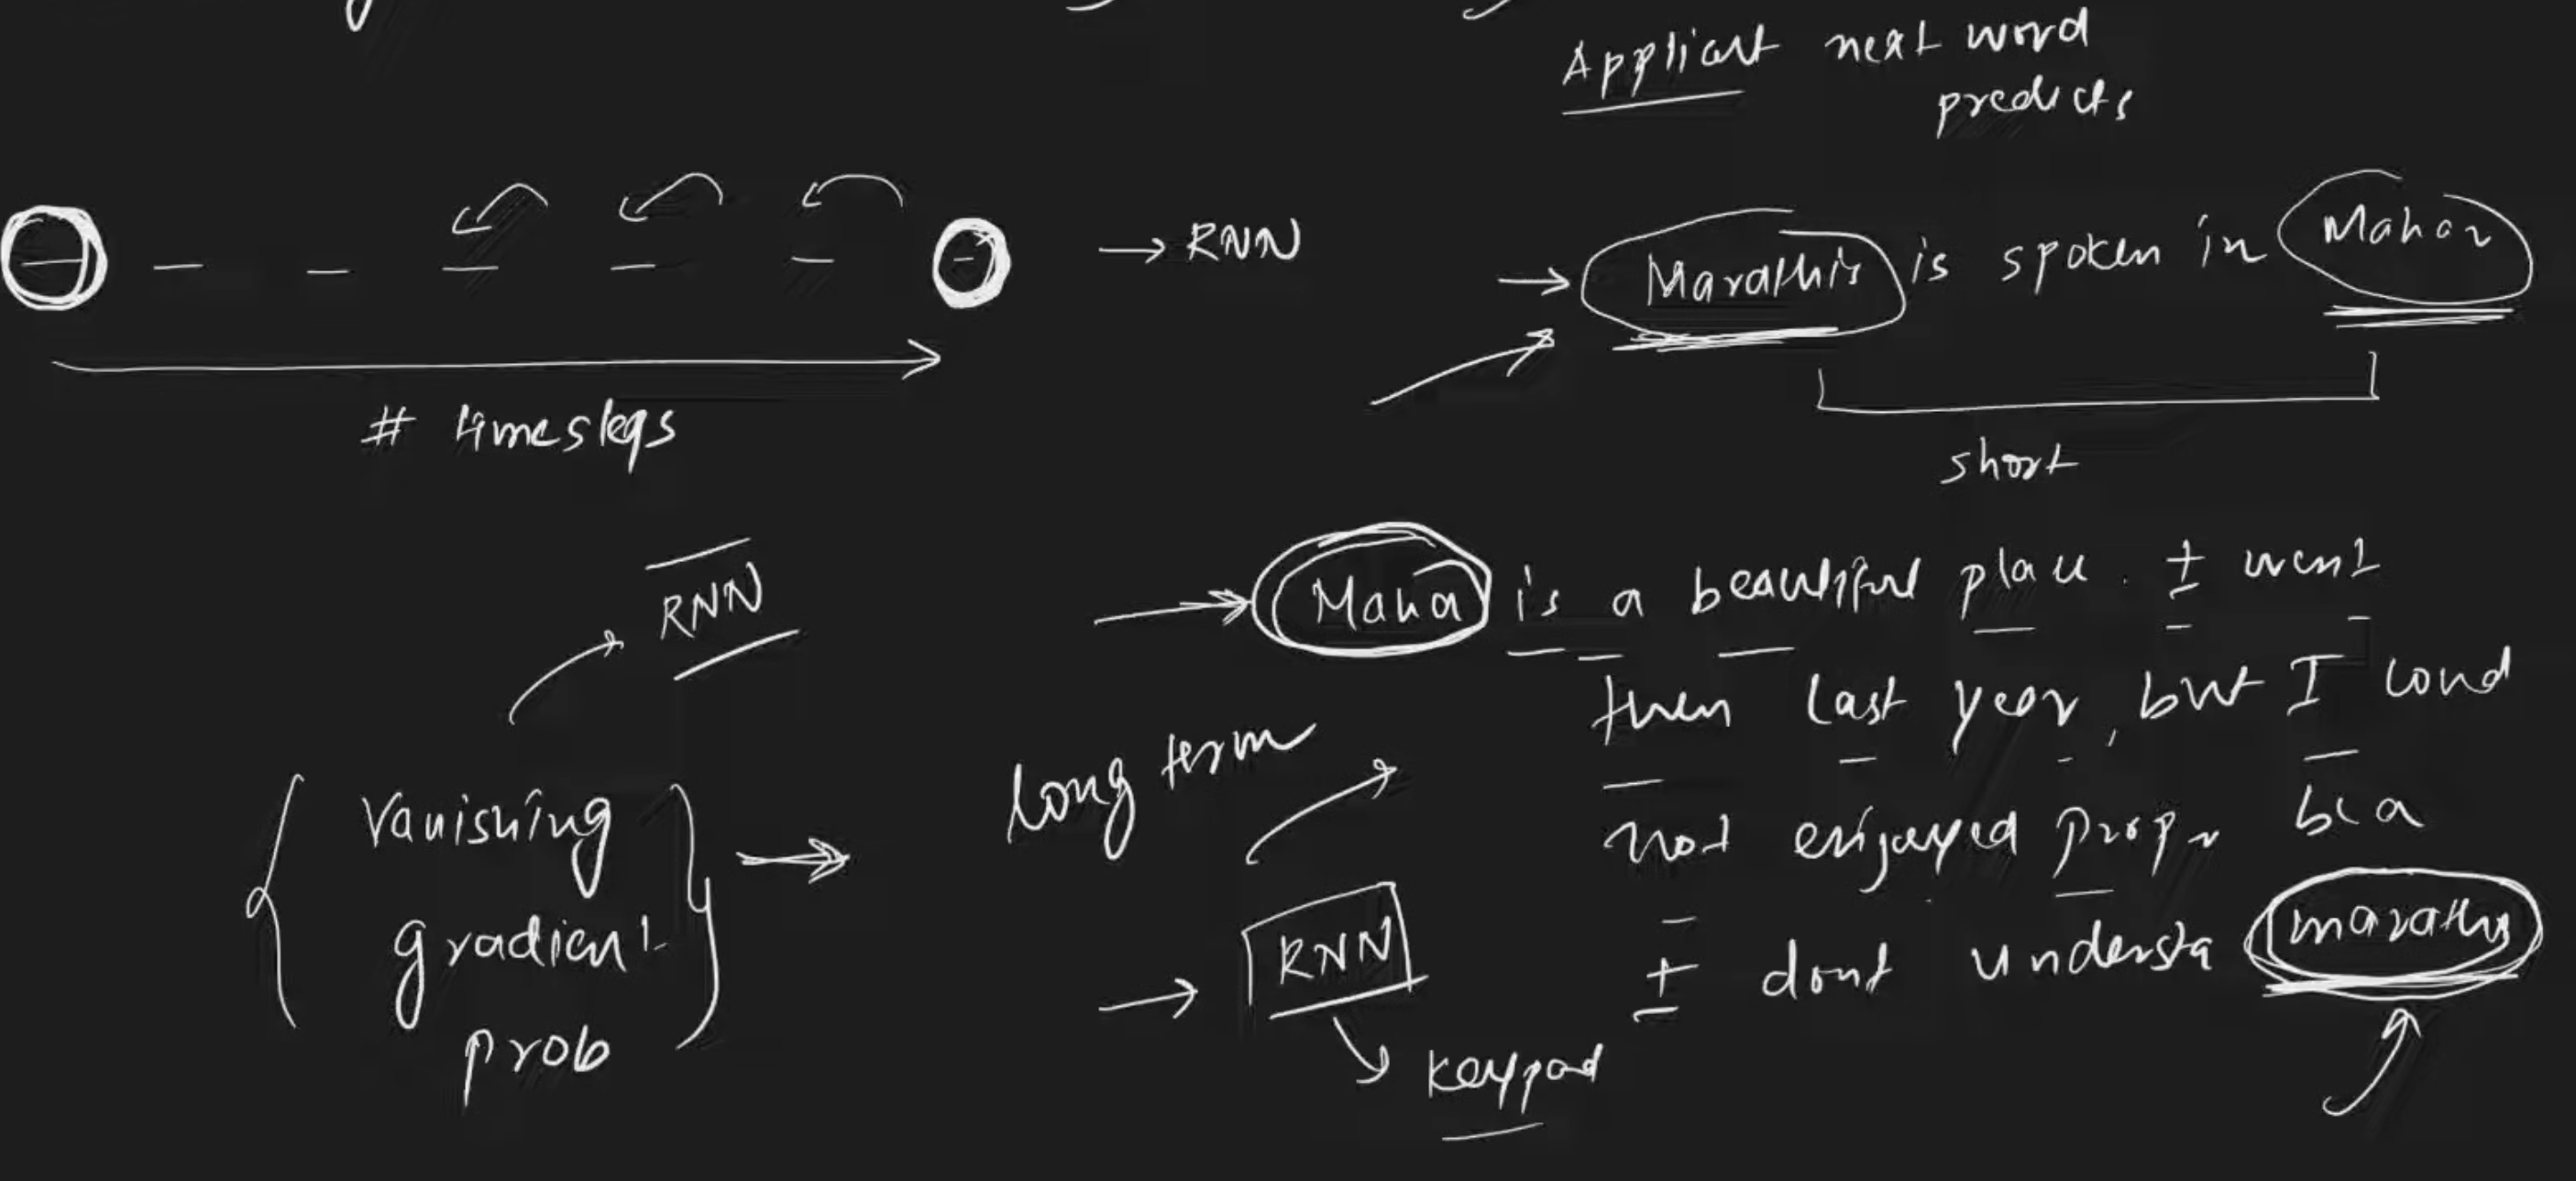
**Why does this happen mathematically?**


The problem stems from the **vanishing gradient** during backpropagation:

1. During training, we compute gradients to update weights
2. These gradients are multiplied at each time step
3. Each multiplication involves the derivative of the activation function (tanh)
4. The derivative of tanh is between 0 and 1
5. Multiplying numbers between 0 and 1 repeatedly makes them **exponentially smaller**
6. After many time steps (say 100), the gradient becomes **effectively zero**

**The Formula:**
For a long-term dependency (connecting time step t to a distant past time step k):

```
∂L/∂W ∝ Π (derivative of tanh) × (weight matrix)
```

- As the sequence length increases, more terms are multiplied
- Each term is ≤ 1 (from tanh derivative)
- Result: The product approaches **zero**
- The contribution of distant inputs to the loss becomes **negligible**

**Consequence:**
- The network only learns from **recent inputs**
- Long-range patterns are ignored
- Performance degrades on long sequences

---

#### Problem 2: Unstable Training (Exploding Gradient)

**What it means:**
The exact opposite of vanishing gradient. Gradients become **extremely large**, causing numerical overflow and unstable training.

**Why does this happen?**

Two main scenarios:

**Scenario 1: Activation function choice**
- If you use an activation function like ReLU (or even tanh with certain conditions)
- The derivative can be > 1
- Multiplying numbers > 1 repeatedly → **exponential growth**
- Gradients approach **infinity**

**Scenario 2: High learning rate**
- If the learning rate is set too high
- Weight updates become massive
- Gradients "explode" and values become NaN (Not a Number)

**Mathematical insight:**
```
If derivative of activation > 1 and weights > 1:
    Product over 100 time steps ≈ 2^100 → INFINITY
```

**Consequences:**
- Weight values become **infinitely large**
- Model training **fails completely**
- Loss function becomes NaN and cannot be computed
- The model cannot learn anything

---

### Summary of the Two Problems

| Problem | What Happens | Cause | Result |
|---------|--------------|-------|--------|
| **Vanishing Gradient** | Gradients become close to 0 | Multiplying derivatives < 1 repeatedly | Can't learn long-term dependencies; only remembers recent inputs |
| **Exploding Gradient** | Gradients become infinite | Multiplying derivatives > 1 or high learning rate | Training fails; weights become NaN |

---

## 3. Key Points

- **RNNs are designed for sequential data** — but have critical flaws
- **Long-term dependency problem**: Can't remember distant past information due to vanishing gradients
- **Vanishing gradient**: Gradients get multiplied by numbers < 1, becoming zero after many time steps
- **Short-term dependency**: RNNs only remember recent inputs, not old ones
- **Exploding gradient**: Opposite problem where gradients become infinite
- **Unstable training**: Model fails to converge or produces NaN values
- These problems **motivated the creation of LSTM** (Long Short-Term Memory) architectures
- LSTMs solve both issues through gating mechanisms

---

## 4. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|--------------|
| **Thinking RNNs are always bad** | RNNs work well for short sequences but fail for long ones | Know your sequence length; use RNNs only for short sequences |
| **Confusing vanishing vs exploding** | Vanishing = gradients become zero; Exploding = gradients become infinite | Remember: "vanishing" = disappearing (→0), "exploding" = blowing up (→∞) |
| **Not understanding why long-term dependency fails** | It's not about memory capacity; it's about gradient math | Think of it as multiplying small numbers repeatedly |
| **Assuming all activation functions work** | Activation functions with derivatives < 1 cause vanishing; > 1 cause exploding | Choose carefully or use architectures like LSTM that handle this |

---

## 5. Interview/Exam Questions

**Q1: Why can't RNNs handle long sequences effectively?**

**Answer:** RNNs suffer from the vanishing gradient problem. During backpropagation through time, gradients are multiplied by the derivative of the activation function (usually tanh, derivative between 0 and 1) at each time step. After many time steps, these gradients become exponentially small (approaching zero). This means the network cannot learn from distant past inputs and only remembers recent data.

---

**Q2: What is the difference between vanishing gradient and exploding gradient?**

**Answer:** 
- **Vanishing gradient**: Gradients become very close to zero because of repeated multiplication by numbers < 1. The network can't learn long-term dependencies.
- **Exploding gradient**: Gradients become extremely large (approaching infinity) because of repeated multiplication by numbers > 1 or due to a high learning rate. Training becomes unstable and weights may become NaN.

Both problems prevent the RNN from being trained effectively.

---

**Q3: Explain the term "long-term dependency" with an example.**

**Answer:** Long-term dependency refers to a situation where the output at a given time step depends on an input from many time steps earlier.

**Example:** "Marathi is spoken in Maharashtra"

The word "Marathi" appears early in the sentence, and it determines what language is predicted later. An RNN with 100 time steps would forget "Marathi" because the gradient signal from that early word becomes too small to influence the current prediction.

---

**Q4: How does the tanh activation function contribute to the vanishing gradient problem?**

**Answer:** The derivative of tanh is between 0 and 1 (specifically, it's `1 - tanh²(x)`, which ranges from 0 to 1). During backpropagation through time, the gradient is multiplied by this derivative at each time step. When you multiply many numbers between 0 and 1 together, the product becomes exponentially smaller, approaching zero. This causes the vanishing gradient problem.

---

**Q5: What are possible solutions to the vanishing gradient problem in RNNs?**

**Answer:** Three solutions mentioned in the transcript:
1. **Use different activation functions** — e.g., ReLU whose derivative is 1 for positive inputs
2. **Better weight initialization** — initialize weights as identity matrices so multiplication doesn't reduce the signal
3. **Use advanced architectures** — like LSTMs or GRUs that are specifically designed to handle long-term dependencies

---

## 6. Revision Notes

- **RNN**: Neural network for sequential data
- **Two problems**: Vanishing gradient and exploding gradient
- **Vanishing gradient**: Gradients → 0; can't learn long-term patterns; only short-term memory
- **Exploding gradient**: Gradients → ∞; training becomes unstable; weights become NaN
- **Root cause**: Repeated multiplication of derivatives during backpropagation through time
- **Tanh derivative**: Between 0 and 1 → causes vanishing
- **High learning rate** → causes exploding
- **Solutions**: Better activation functions, weight initialization, advanced architectures (LSTM)
- **Why LSTM?** It was created specifically to solve these problems
- **Key takeaway**: RNNs are powerful but fundamentally limited; understanding these limitations is crucial before moving to LSTMs

---



# Topic 2: Backpropagation Through Time (BPTT) and Gradient Mathematics

## 1. Introduction

**What it is:**
Backpropagation Through Time (BPTT) is the training algorithm used for RNNs. It's an extension of standard backpropagation that accounts for the temporal (time-based) nature of sequential data.

**Why it's important:**
Understanding BPTT is essential to grasp *why* vanishing and exploding gradients occur. The mathematical structure of BPTT reveals exactly how gradients propagate through time steps and why long-term dependencies fail.

**Real-life use:**
BPTT is the foundation for training all recurrent architectures. Even modern LSTMs and GRUs use variations of this algorithm. Without BPTT, RNNs couldn't learn patterns in sequences at all.

---

## 2. Detailed Explanation

### What is Backpropagation Through Time?

In a standard neural network, backpropagation computes gradients by going backward through the network layers.

In an RNN, the network is "unfolded" or "unrolled" across time steps. Each time step becomes a separate layer in the unfolded network.

**The Unfolding Process:**

Imagine an RNN with 3 time steps (t=1, t=2, t=3):

```
Original RNN:          Unfolded RNN:

     y1  y2  y3           y1 ←  y2 ←  y3
     ↑   ↑   ↑            ↑     ↑     ↑
     h1→h2→h3           h1 →  h2 →  h3
     ↑   ↑   ↑            ↑     ↑     ↑
     x1  x2  x3           x1    x2    x3
```

- At each time step, we have an input (x), hidden state (h), and output (y)
- The same weight matrices (W_in, W_h, W_out) are shared across all time steps
- "Unfolding" means we duplicate the network for each time step
- The shared weights create dependencies across all time steps

---

### The Architecture Components

For an RNN with the following configuration:

**Notation:**
- **x_t**: Input at time step t
- **h_t**: Hidden state at time step t
- **o_t**: Output at time step t
- **y_t**: Target (desired output) at time step t
- **W_in**: Weight matrix from input to hidden layer
- **W_h**: Weight matrix from hidden to hidden (recurrent weight)
- **W_out**: Weight matrix from hidden to output

**Forward Pass Equations:**
```
h_t = tanh(W_in · x_t + W_h · h_{t-1})
o_t = W_out · h_t
```
- The hidden state h_t depends on current input AND previous hidden state h_{t-1}
- This creates the "memory" in the RNN

**Backward Pass (BPTT):**

During backpropagation, we compute gradients of the loss (L) with respect to each weight matrix:

```
∂L/∂W_in, ∂L/∂W_h, ∂L/∂W_out
```

---

### The Key Insight: Gradient Contributions

This is where the problem becomes clear.

**The Loss at time step 3 (L₃) depends on:**
- W_out directly
- W_h directly
- W_in directly

**But also indirectly through previous time steps!**

The loss at time step 3 depends on:
- h₃ → depends on h₂ and W_h
- h₂ → depends on h₁ and W_h
- h₁ → depends on x₁ and W_in

**Critical Point:**
The gradient ∂L₃/∂W_in has **multiple paths**:

1. **Short-term path**: L₃ → o₃ → h₃ → W_in (direct)
2. **Long-term path**: L₃ → o₃ → h₃ → h₂ → h₁ → W_in (through all time steps)

---

### Mathematical Derivation of Long-Term Dependency

For a loss at time step T (the final output):

**∂L_T/∂W_in** can be expanded as:

```
∂L_T/∂W_in = ∑_{k=1}^T [∂L_T/∂o_T · ∂o_T/∂h_T · ∂h_T/∂h_k · ∂h_k/∂W_in]
```

The term `∂h_T/∂h_k` represents how the hidden state at time T depends on the hidden state at time k.

**Expanding ∂h_T/∂h_k:**

```
∂h_T/∂h_k = ∏_{i=k+1}^T [∂h_i/∂h_{i-1}]
```

Each `∂h_i/∂h_{i-1}` is the derivative of the activation function (tanh) times the weight matrix:

```
∂h_i/∂h_{i-1} = W_h · tanh'(W_in·x_i + W_h·h_{i-1})
```

**The Long-Term Dependency Formula:**

For the oldest dependency (k=1):

```
∂h_T/∂h_1 = ∏_{i=2}^T [W_h · tanh'(...)]
```

**If T=100 time steps:**
```
∂h_100/∂h_1 = [W_h · tanh']^98
```

---

### Why This Causes Vanishing Gradients

**Case 1: Vanishing Gradient**

Given:
- tanh'(x) is between 0 and 1
- If we initialize W_h properly, its values are also ≤ 1

```
For T = 100:
∂h_100/∂h_1 = (0.9)^98 ≈ 0.00003
```

The contribution of the first input (x₁) to the final loss is **extremely small**.

**In words:**
- The oldest inputs have almost no influence on the gradient
- The network can't learn to use old information
- Only recent inputs (k close to T) contribute significantly

**Visual Representation:**

```
Time step contribution to gradient:
t=100: ████████████ (high contribution)
t=90:  ██████████   (medium contribution)
t=50:  ████         (low contribution)
t=1:   █            (almost zero)
```

---

### Why This Causes Exploding Gradients

**Case 2: Exploding Gradient**

If the product exceeds 1:

```
If W_h · tanh'(...) = 1.5
For T = 100:
(1.5)^98 ≈ 3.6 × 10^17 (HUGE!)
```

The gradient becomes **astronomically large**, leading to:
- Weight updates that are too large
- Numerical overflow (values become infinity)
- Training completely fails

**This can happen when:**
1. Activation function derivative > 1 (e.g., ReLU, or certain regions of tanh)
2. Weight matrix has values > 1
3. Learning rate is too high

---

### The Mathematical Breakdown

**General Formula for Gradient Through Time:**

```
∂L_T/∂W_h = ∑_{k=1}^T [∂L_T/∂o_T · ∂o_T/∂h_T · (∏_{i=k+1}^T ∂h_i/∂h_{i-1}) · ∂h_k/∂W_h]
```

**Components:**
- **Outer sum**: Sums over all time steps k
- **Product term**: The "chain" of dependencies from k to T
- The product term is what causes the problems

**Short-term dependency** (k close to T):
- Fewer multiplications
- Product remains non-zero
- Gradient is healthy

**Long-term dependency** (k far from T):
- Many multiplications
- Product either → 0 or → ∞
- Gradient is either zero or infinite

---

## 3. Key Points

- **BPTT** = Backpropagation Through Time; the training algorithm for RNNs
- **Unfolding**: RNN is expanded across time steps, creating a deep network
- **Shared weights**: W_in, W_h, W_out are the same at every time step
- **Gradient has multiple paths**: Short-term and long-term dependencies
- **Long-term dependency formula**: Product of derivatives and weights over many time steps
- **If product < 1**: Vanishing gradient → can't learn long patterns
- **If product > 1**: Exploding gradient → training becomes unstable
- **The core issue**: Repeated multiplication causes exponential behavior

---

## 4. Syntax/Structure (The Mathematical Representation)

**Forward Pass Structure:**

| Component | Formula | Description |
|-----------|---------|-------------|
| Hidden state | `h_t = tanh(W_in · x_t + W_h · h_{t-1})` | Current state depends on input and previous state |
| Output | `o_t = W_out · h_t` | Output depends on current hidden state |

**Backward Pass Structure:**

| Component | Formula | Description |
|-----------|---------|-------------|
| Loss at time T | `L_T` | Total loss at final time step |
| Gradient (short) | `∂L_T/∂W_h ≈ ∂L_T/∂h_T · ∂h_T/∂W_h` | Direct contribution |
| Gradient (long) | `∂L_T/∂W_h ≈ ∂L_T/∂h_T · (∏_{i=k+1}^T ∂h_i/∂h_{i-1}) · ∂h_k/∂W_h` | Contribution from past |

---

## 5. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|--------------|
| **Thinking BPTT is the same as standard backpropagation** | BPTT has to account for temporal dependencies across time | Remember that weights are shared and gradients flow backward through time |
| **Confusing unfolding with actual different networks** | The unfolded network represents the same RNN at different times; it's not multiple networks | Understand that the same weights are reused at each time step |
| **Not seeing why long-term dependency fails** | It's about the product of derivatives, not about sequence length directly | Always think: "What happens when I multiply this 100 times?" |
| **Ignoring the effect of activation functions** | Tanh derivative being < 1 is the primary cause of vanishing gradient | Pay attention to derivative ranges when choosing activation functions |

---

## 6. Interview/Exam Questions

**Q1: Explain the concept of "unfolding" an RNN and why it's necessary for backpropagation.**

**Answer:** Unfolding is the process of expanding an RNN across time steps, creating a sequence of identical networks. It's necessary because:
- In an RNN, the hidden state depends on previous states
- To compute gradients, we need to see all dependencies across time
- Unfolding converts temporal dependencies into layer dependencies
- This allows us to apply standard backpropagation principles

**Example:** An RNN with 3 time steps unfolds into 3 layers, with weights shared across layers.

---

**Q2: What is the expression for the gradient of the loss at time T with respect to W_h (recurrent weight)?**

**Answer:**

```
∂L_T/∂W_h = ∑_{k=1}^T [∂L_T/∂o_T · ∂o_T/∂h_T · (∏_{i=k+1}^T ∂h_i/∂h_{i-1}) · ∂h_k/∂W_h]
```

Where `∂h_i/∂h_{i-1} = W_h · tanh'(W_in·x_i + W_h·h_{i-1})`

This sum shows that the gradient includes contributions from all past time steps, but the product term determines whether these contributions are meaningful.

---

**Q3: In the gradient expression ∂h_T/∂h_k, what does this term represent and why does it cause problems?**

**Answer:** `∂h_T/∂h_k` represents how much the hidden state at time T (the final state) depends on the hidden state at time k (a past state).

It causes problems because:
```
∂h_T/∂h_k = ∏_{i=k+1}^T [W_h · tanh'(...)]
```
- If each factor is < 1, the product → 0 (vanishing)
- If each factor is > 1, the product → ∞ (exploding)
- This means the influence of past states on the final state is either negligible or overwhelming

---

**Q4: Why does using tanh as an activation function specifically cause vanishing gradients?**

**Answer:** The derivative of tanh is `1 - tanh²(x)`, which is always between 0 and 1. During backpropagation, this derivative is multiplied at each time step. When you multiply many numbers < 1 together:

```
0.9 × 0.9 × 0.9 × ... = exponentially approaching 0
```

This makes the gradient of long-term dependencies effectively zero, so the network can't learn from distant inputs.

---

**Q5: How does the number of time steps affect the vanishing gradient problem?**

**Answer:** The vanishing gradient problem worsens with more time steps because:
- The product has more factors to multiply
- With each additional time step, the gradient gets smaller
- Longer sequences → more severe vanishing

**Example:**
- 10 time steps: gradient might be 0.9¹⁰ ≈ 0.35 (still meaningful)
- 50 time steps: gradient might be 0.9⁵⁰ ≈ 0.005 (very small)
- 100 time steps: gradient might be 0.9¹⁰⁰ ≈ 0.00003 (effectively zero)

---

## 7. Revision Notes

- **BPTT** = RNN training algorithm; unfolds network across time
- **Unfolding**: Convert temporal sequence into layered network
- **Forward pass**: `h_t = tanh(W_in·x_t + W_h·h_{t-1})`, `o_t = W_out·h_t`
- **Gradient formula**: Sum over all past time steps with product of derivatives
- **Product term**: `∏ [W_h · tanh']` → the source of problems
- **Vanishing**: Product < 1 → gradient → 0 → can't learn old patterns
- **Exploding**: Product > 1 → gradient → ∞ → training fails
- **Short-term dependencies**: Fewer multiplications → gradients survive
- **Long-term dependencies**: Many multiplications → gradients vanish/explode
- **BPTT mathematically proves** why RNNs fail on long sequences

---

**Next topic covers:** Solutions to these gradient problems (activation functions, weight initialization, gradient clipping) and why we need LSTMs.



# Topic 3: Solutions to Gradient Problems and Introduction to LSTM

## 1. Introduction

**What it is:**
This topic covers practical solutions to the vanishing and exploding gradient problems in RNNs, and introduces why the **LSTM (Long Short-Term Memory)** architecture was developed as the definitive solution.

**Why it's important:**
While RNNs have fundamental flaws, understanding the solutions helps you appreciate:
- Why certain design choices matter in deep learning
- How modern architectures evolved
- Why LSTMs became the standard for sequence tasks until transformers emerged

**Real-life use:**
- **Gradient clipping** is still used today in training transformers and large language models
- **LSTMs** were the state-of-the-art for machine translation, speech recognition, and time series forecasting for many years
- Understanding these solutions helps you debug training issues in any neural network

---

## 2. Detailed Explanation

### Part A: Solutions to Vanishing Gradient Problem

The vanishing gradient problem occurs because:
- Activation function derivatives are < 1
- Multiplying them repeatedly makes gradients → 0

**Solution 1: Use Different Activation Functions**

| Activation Function | Derivative Range | Suitability for RNN |
|---------------------|------------------|---------------------|
| **Tanh** | 0 to 1 | Causes vanishing gradient ❌ |
| **Sigmoid** | 0 to 0.25 | Even worse for vanishing ❌ |
| **ReLU** | 0 or 1 | Better, but can cause exploding |
| **Leaky ReLU** | Small positive (0.01) to 1 | May help with vanishing |
| **ELU** | 0 to 1 (negative part) | Alternative option |

**Why ReLU helps:**
- Derivative is 1 for positive inputs
- Multiplying by 1 doesn't reduce the gradient
- Problem: ReLU can cause **exploding** gradients if weights > 1

**Why changing activation isn't a complete solution:**
- ReLU solves vanishing but introduces exploding risk
- You also need to control weight initialization
- The problem shifts rather than disappears

---

**Solution 2: Better Weight Initialization**

**The Idea:**
If we initialize the weight matrix **W_h** properly, we can prevent gradients from shrinking.

**Identity Matrix Initialization:**
- Initialize W_h as an identity matrix (I)
- Multiplying by identity matrix: `I × x = x` (no change)
- This prevents the gradient from being scaled down

**Why it helps:**
```
If W_h ≈ I:
∂h_i/∂h_{i-1} = I × tanh'(...) ≈ tanh'(...)
```
The gradient is only affected by the derivative, not the weight matrix.

**Other initialization techniques:**
- **Xavier/Glorot initialization**: Keeps variance of activations constant
- **He initialization**: Specifically for ReLU networks
- **Orthogonal initialization**: Ensures weights are orthogonal, preserving gradient norms

---

**Solution 3: Architectural Changes**

**Skipping Connections (Skip Connections):**
- Add direct connections that skip time steps
- Allows gradients to flow more directly
- Partially preserves information from distant past

**Example of Skip Connection:**
```
h_t = tanh(W_in·x_t + W_h·h_{t-1}) + h_{t-2}
```
The hidden state at time t gets a "copy" from two time steps ago.

**These solutions are partial fixes:**
- They help but don't fully solve the problem
- They work for moderate sequence lengths
- For long sequences (100+ steps), they still fail

---

### Part B: Solutions to Exploding Gradient Problem

**Solution: Gradient Clipping**

**What it is:**
A technique that caps the gradient value to a maximum threshold.

**How it works:**

```
If ||gradient|| > threshold:
    gradient = gradient × (threshold / ||gradient||)
```

**Pseudo-code:**
```
# Calculate gradient normally
gradient = compute_gradient()

# Check magnitude
if norm(gradient) > max_norm:
    # Scale down
    gradient = gradient * (max_norm / norm(gradient))

# Update weights
weights = weights - learning_rate * gradient
```

**Why it works:**
- Prevents gradients from becoming infinitely large
- Keeps training stable
- Works even if the underlying problem persists

**Visual explanation:**

```
Without clipping:    gradient = 1,000,000 → weights blow up ❌
With clipping:       gradient = 5 (capped) → stable training ✅
```

**Types of Gradient Clipping:**
1. **Norm clipping**: Caps the L2 norm of the entire gradient vector
2. **Value clipping**: Caps each individual gradient value to a range [-max, max]

**Note:** Gradient clipping is a **band-aid solution**; it doesn't fix the root cause but makes training possible.

---

### Part C: Why We Still Needed a Better Solution

**The Reality Check:**

| Solution | Problems It Solves | Limitations |
|----------|-------------------|-------------|
| **Better activation functions** | Vanishing | Can cause exploding; doesn't work for long sequences |
| **Better weight initialization** | Vanishing | Initialization helps but doesn't guarantee stability |
| **Skip connections** | Vanishing (partial) | Complex to implement; still fails on very long sequences |
| **Gradient clipping** | Exploding | Doesn't address vanishing; is a hack, not a solution |

**The Fundamental Issue Remains:**
- RNNs have a **single hidden state** that must:
  - Remember old information
  - Process new information
  - Decide what to forget
- This is too much for one state to handle!

**What we need:**
- A mechanism to **selectively remember and forget**
- Ability to decide what's important and what's not
- Architecture that controls information flow

**This is where LSTM comes in!**

---

### Part D: Introduction to LSTM

**What is LSTM?**
**Long Short-Term Memory (LSTM)** is an advanced RNN architecture specifically designed to solve the vanishing gradient problem.

**Key Insight:**
Instead of having a single hidden state, LSTM has:
1. **Cell state (c_t)**: Long-term memory that flows through time with little modification
2. **Hidden state (h_t)**: Short-term memory used for output

**The Gating Mechanism:**
LSTM uses three "gates" that control information flow:

| Gate | Purpose | Analogy |
|------|---------|---------|
| **Forget Gate** | Decides what to discard from old memory | "Should I forget this old thought?" |
| **Input Gate** | Decides what new information to store | "Should I remember this new thought?" |
| **Output Gate** | Decides what to output based on memory | "What should I say based on what I know?" |

**Why LSTM Solves Vanishing Gradients:**

**Key mechanism: The cell state pathway**
- The cell state (c_t) is updated by **addition**, not multiplication
- Addition prevents gradients from shrinking
- The gradient flows through the cell state **almost unchanged**

```
Vanilla RNN:    h_t = tanh(W·h_{t-1})  [MULTIPLICATION → vanishing]
LSTM:           c_t = c_{t-1} + new   [ADDITION → gradient preserves]
```

---

### Summary of Solutions

**Complete Solution Approach:**

| Problem | Partial Solution | Complete Solution |
|---------|------------------|-------------------|
| **Vanishing Gradient** | ReLU activation, identity initialization | LSTM (cell state with additive updates) |
| **Exploding Gradient** | Gradient clipping | LSTM + gradient clipping (combined) |

---

## 3. Key Points

- **Vanishing gradient solutions**: Better activations (ReLU), better initialization (identity matrix), skip connections
- **Exploding gradient solutions**: Gradient clipping (capping values to a maximum)
- **Gradient clipping**: Prevents gradients from growing too large; caps at a threshold
- **All RNN solutions are partial**: They help but don't fully solve the problem for long sequences
- **LSTM was developed** as the definitive solution to both gradient problems
- **LSTM has a cell state**: Long-term memory that persists through time
- **LSTM uses gates**: Forget, Input, Output to control information flow
- **Additive updates** (not multiplicative) are the key to preventing vanishing gradients

---

## 4. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|--------------|
| **Thinking gradient clipping solves everything** | Clipping only fixes exploding, not vanishing | Use LSTM for long sequences; clipping is extra protection |
| **Changing activation function without considering consequences** | ReLU helps vanishing but can cause exploding | Always pair activation changes with appropriate initialization |
| **Using LSTM without understanding why it works** | LSTM's additive updates are the key, not the complexity | Understand that addition prevents gradient from shrinking |
| **Trying to "fix" RNN instead of using LSTM** | RNNs are fundamentally limited; no amount of tricks makes them perfect for long sequences | For any real-world sequence task, use LSTM or transformer |

---

## 5. Interview/Exam Questions

**Q1: What are three ways to address the vanishing gradient problem in RNNs?**

**Answer:** 
1. **Use different activation functions** — e.g., ReLU whose derivative is 1 for positive inputs
2. **Better weight initialization** — e.g., identity matrix initialization so multiplication doesn't reduce the gradient
3. **Use skip connections** — add direct paths that allow gradients to bypass many time steps

These help but don't fully solve the problem for long sequences, which is why LSTM was developed.

---

**Q2: What is gradient clipping and when is it used?**

**Answer:** Gradient clipping is a technique that caps the magnitude of gradients to a maximum value. If the gradient norm exceeds a threshold, it's scaled down.

**When used:**
- To prevent exploding gradients in RNNs
- During training when gradients become extremely large
- As a safeguard against numerical instability

**Example:** If threshold is 5.0 and gradient norm is 10.0, the gradient is scaled down to 5.0.

---

**Q3: Why is gradient clipping a "band-aid" solution rather than a fix?**

**Answer:** Gradient clipping addresses the symptom (large gradients) but not the root cause. The root cause is the repeated multiplication of derivatives and weights through many time steps. Clipping simply prevents these values from growing to infinity; it doesn't help the network learn long-term dependencies. For that, you need an architecture like LSTM that fundamentally changes how information flows through time.

---

**Q4: How does LSTM solve the vanishing gradient problem that plagues vanilla RNNs?**

**Answer:** LSTM solves the vanishing gradient problem through its **cell state** and **additive updates**:

1. **Cell state (c_t)**: A separate memory path that flows through time
2. **Additive updates**: Instead of `c_t = W·c_{t-1}` (multiplication), LSTM uses `c_t = c_{t-1} + new_info` (addition)
3. **Gradient flow**: During backpropagation, the gradient from the cell state doesn't get multiplied repeatedly
4. **Result**: Gradients can flow through many time steps without vanishing

The addition operation means the gradient of c_t with respect to c_{t-1} is 1, not a product of many small numbers.

---

**Q5: What is the role of the forget gate in LSTM?**

**Answer:** The forget gate decides what information to discard from the cell state. It outputs values between 0 and 1:
- **0**: Completely forget this information
- **1**: Completely keep this information

This allows the LSTM to selectively forget irrelevant information and maintain only what's needed for long-term dependencies.

---

## 6. Revision Notes

- **Vanishing gradient fixes**: ReLU, identity initialization, skip connections
- **Exploding gradient fix**: Gradient clipping
- **Gradient clipping**: Capping gradients to a maximum value (e.g., norm ≤ 5)
- **None of these fully solve RNN problems**: They're partial solutions
- **LSTM = Long Short-Term Memory**: Designed specifically to solve vanishing gradient
- **Key LSTM innovation**: Cell state with **additive** (not multiplicative) updates
- **Additive updates**: `c_t = c_{t-1} + Δc` → gradient remains stable
- **LSTM gates**: Forget (discard), Input (add new), Output (use memory)
- **LSTM solves**: Vanishing gradient (through addition) and helps with exploding (through gating)
- **Real-world conclusion**: Use LSTM (or transformers) for any sequence task with long dependencies

---

**Next topic covers:** A deeper look at LSTM architecture, its components, and how gates work in detail.

